# Automated Diabetic Retinopathy Detection and Grading from Retinal Fundus Images Using EfficientNet-B3

---

**Author:** Uon Chamroeun  
**Project Type:** MEng Thesis / Research Project  
**Last Updated:** March 2026

---

## Abstract

Diabetic Retinopathy (DR) is one of the leading causes of preventable blindness worldwide, affecting an estimated 103 million people globally. Early detection through automated screening of retinal fundus images can significantly reduce the burden on ophthalmologists and improve patient outcomes, particularly in resource-limited settings.

This project presents a comprehensive deep learning pipeline for automated DR detection and severity grading using **EfficientNet-B3** pretrained on ImageNet. The system operates at two levels:

1. **Binary Classification** — detecting the presence or absence of DR
2. **Multi-class Ordinal Grading** — classifying fundus images into five severity levels (No DR, Mild NPDR, Moderate NPDR, Severe NPDR, and Proliferative DR) according to the International Clinical Diabetic Retinopathy (ICDR) severity scale

Three publicly available fundus image datasets — **APTOS 2019**, **IDRiD**, and **Messidor-2** — are merged into a unified dataset of **6,804 unique images** after MD5 hash-based cross-dataset deduplication.

## Key Features

- **Multi-dataset fusion** — 3 public datasets merged with hash-based deduplication (6,804 images)
- **Two-level classification** — Binary (DR vs No DR) and ordinal 5-class grading (Grade 0-4)
- **Clinical-grade preprocessing** — Ben Graham's method with CLAHE enhancement and circle cropping
- **Rigorous evaluation** — 5-Fold stratified cross-validation, bootstrap CIs, calibration analysis
- **Test-Time Augmentation (TTA)** — 8x TTA for improved inference robustness
- **Cross-dataset generalization** — Trained on merged data, evaluated on APTOS and IDRiD independently
- **Reproducible pipeline** — End-to-end Jupyter notebooks from raw data to predictions

---

## 1. Environment & Imports

In [4]:
import os
import json
import hashlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display, Markdown, HTML

import warnings
warnings.filterwarnings('ignore')

# Configuration
ROOT = Path('.')
SEED = 42
np.random.seed(SEED)

print('Environment ready.')

Environment ready.


---

## 2. Datasets Overview

Three publicly available retinal fundus image datasets are merged into a single unified dataset with MD5 hash-based deduplication to remove cross-dataset duplicate images.

| Dataset | Original Images | After Dedup | Labels | Source |
|---------|:---:|:---:|--------|--------|
| **APTOS 2019** | 3,662 | 3,534 | `diagnosis` (0-4) | [Kaggle](https://www.kaggle.com/c/aptos2019-blindness-detection) |
| **IDRiD** | 1,548 | 1,530 | `Retinopathy grade` (0-4) | [IEEE DataPort](https://ieee-dataport.org/open-access/indian-diabetic-retinopathy-image-dataset-idrid) |
| **Messidor-2** | 1,748 | 1,740 | `diagnosis` (0-4) | [ADCIS / LaTIM](https://www.adcis.net/en/third-party/messidor2/) |
| **Total** | **6,958** | **6,804** | | |

### DR Severity Grades (ICDR Scale)

| Grade | Name | Description |
|:---:|------|-------------|
| 0 | No DR | No visible signs of diabetic retinopathy |
| 1 | Mild NPDR | Microaneurysms only |
| 2 | Moderate NPDR | More than just microaneurysms but less than severe |
| 3 | Severe NPDR | Extensive intraretinal hemorrhages, venous beading, IRMA |
| 4 | Proliferative DR | Neovascularization and/or vitreous/preretinal hemorrhage |

### 2.1 Load and Verify Dataset

In [7]:
# Load the merged dataset
df_merged = pd.read_csv(ROOT / 'merged_labels.csv')

print(f'Total images in merged dataset: {len(df_merged):,}')
print(f'Columns: {list(df_merged.columns)}')
print()

# Per-dataset counts
print('=== Per-Dataset Breakdown ===')
for ds in ['aptos2019', 'idrid', 'messidor2']:
    sub = df_merged[df_merged['original_dataset'] == ds]
    print(f'  {ds:12s}: {len(sub):,} images')

print()
df_merged.head()

Total images in merged dataset: 6,804
Columns: ['image_id', 'original_dataset', 'original_label', 'dr_grade', 'binary_label', 'file_path', 'image_hash']

=== Per-Dataset Breakdown ===
  aptos2019   : 3,534 images
  idrid       : 1,530 images
  messidor2   : 1,740 images



,image_id,original_dataset,original_label,dr_grade,binary_label,file_path,image_hash
0,aptos_000c1434d8d7,aptos2019,2,2,1,aptos2019-blindness-detection/train_images/000...,e6155d8339d40577f97a5ce270aa81d1
1,aptos_001639a390f0,aptos2019,4,4,1,aptos2019-blindness-detection/train_images/001...,8f98205b18dfcc9111fe97037d9fe5ba
2,aptos_0024cdab0c1e,aptos2019,1,1,1,aptos2019-blindness-detection/train_images/002...,43e417a95e1259bc318493e399670cb8
3,aptos_002c21358ce6,aptos2019,0,0,0,aptos2019-blindness-detection/train_images/002...,f96db7f8fc458a804b0db13739bc976d
4,aptos_005b95c28852,aptos2019,0,0,0,aptos2019-blindness-detection/train_images/005...,17ecb0becd4bd280b3572ad31dce75b9


In [8]:
# Check original APTOS CSV vs merged (deduplication verification)
aptos_csv = pd.read_csv(ROOT / 'aptos2019-blindness-detection' / 'train.csv')
aptos_merged = df_merged[df_merged['original_dataset'] == 'aptos2019']

print('=== APTOS Deduplication Verification ===')
print(f'Original APTOS CSV:    {len(aptos_csv):,} images')
print(f'APTOS in merged:       {len(aptos_merged):,} images')
print(f'Removed (duplicates):  {len(aptos_csv) - len(aptos_merged):,} images')
print()

# Grade-by-grade breakdown of removed images
print('=== Grade-by-Grade Deduplication ===')
print(f'{"Grade":<8} {"Original":<10} {"After":<10} {"Removed":<10}')
print('-' * 38)
for g in range(5):
    orig = (aptos_csv['diagnosis'] == g).sum()
    after = (aptos_merged['dr_grade'] == g).sum()
    print(f'{g:<8} {orig:<10} {after:<10} {orig - after:<10}')
total_orig = len(aptos_csv)
total_after = len(aptos_merged)
print('-' * 38)
print(f'{"Total":<8} {total_orig:<10} {total_after:<10} {total_orig - total_after:<10}')

=== APTOS Deduplication Verification ===
Original APTOS CSV:    3,662 images
APTOS in merged:       3,534 images
Removed (duplicates):  128 images

=== Grade-by-Grade Deduplication ===
Grade    Original   After      Removed   
--------------------------------------
0        1805       1798       7         
1        370        341        29        
2        999        934        65        
3        193        182        11        
4        295        279        16        
--------------------------------------
Total    3662       3534       128       


### 2.2 Class Distribution Analysis

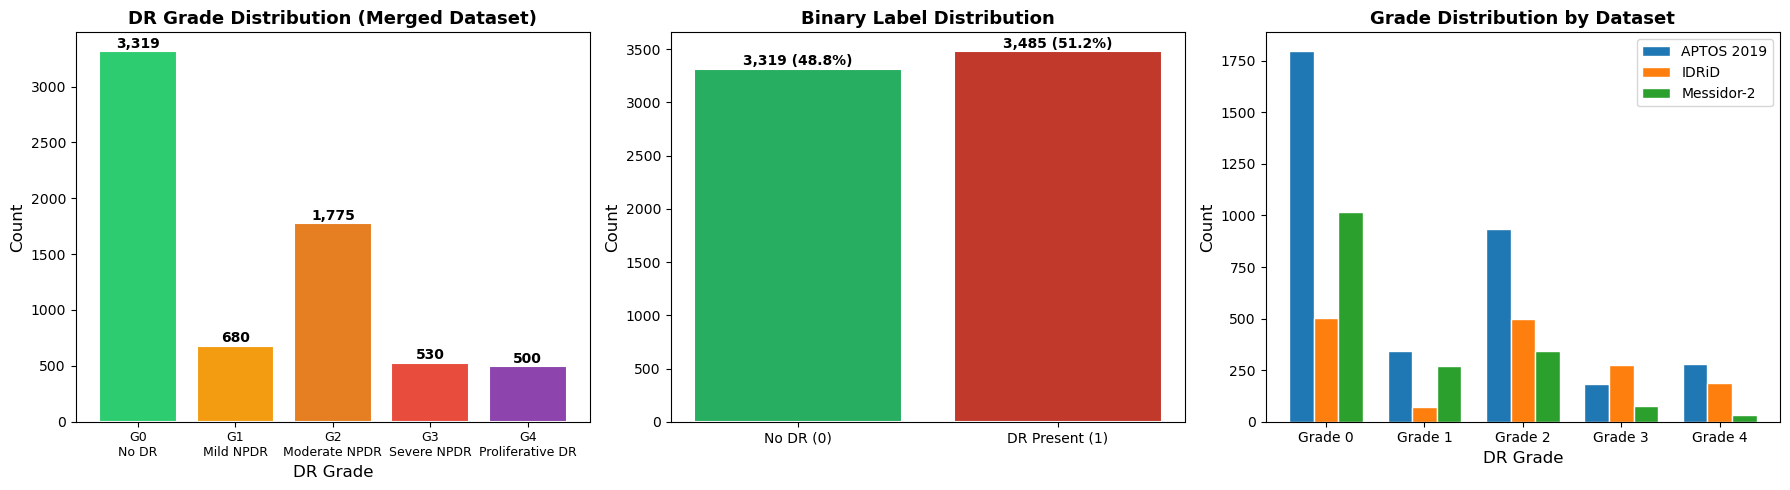


=== Dataset Summary Statistics ===
APTOS 2019     : 3,534 images | DR prevalence: 49.1%
IDRiD          : 1,530 images | DR prevalence: 67.1%
Messidor-2     : 1,740 images | DR prevalence: 41.6%
MERGED         : 6,804 images | DR prevalence: 51.2%


In [10]:
grade_names = {0: 'No DR', 1: 'Mild NPDR', 2: 'Moderate NPDR', 3: 'Severe NPDR', 4: 'Proliferative DR'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: DR Grade Distribution (Merged) ---
grade_counts = df_merged['dr_grade'].value_counts().sort_index()
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#8e44ad']
bars = axes[0].bar(grade_counts.index, grade_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_xlabel('DR Grade', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('DR Grade Distribution (Merged Dataset)', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(5))
axes[0].set_xticklabels([f'G{i}\n{grade_names[i]}' for i in range(5)], fontsize=9)
for bar, count in zip(bars, grade_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{count:,}', ha='center', fontweight='bold', fontsize=10)

# --- Plot 2: Binary Distribution ---
binary_counts = df_merged['binary_label'].value_counts().sort_index()
binary_labels = ['No DR (0)', 'DR Present (1)']
binary_colors = ['#27ae60', '#c0392b']
bars2 = axes[1].bar(binary_labels, binary_counts.values, color=binary_colors, edgecolor='white', linewidth=1.5)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Binary Label Distribution', fontsize=13, fontweight='bold')
for bar, count in zip(bars2, binary_counts.values):
    pct = count / len(df_merged) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{count:,} ({pct:.1f}%)', ha='center', fontweight='bold', fontsize=10)

# --- Plot 3: Per-Dataset Stacked ---
datasets = ['aptos2019', 'idrid', 'messidor2']
ds_labels = ['APTOS 2019', 'IDRiD', 'Messidor-2']
x = np.arange(5)
width = 0.25
for i, (ds, label) in enumerate(zip(datasets, ds_labels)):
    sub = df_merged[df_merged['original_dataset'] == ds]
    counts = [len(sub[sub['dr_grade'] == g]) for g in range(5)]
    axes[2].bar(x + i * width, counts, width, label=label, edgecolor='white')
axes[2].set_xlabel('DR Grade', fontsize=12)
axes[2].set_ylabel('Count', fontsize=12)
axes[2].set_title('Grade Distribution by Dataset', fontsize=13, fontweight='bold')
axes[2].set_xticks(x + width)
axes[2].set_xticklabels([f'Grade {i}' for i in range(5)])
axes[2].legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print('\n=== Dataset Summary Statistics ===')
for ds, label in zip(datasets, ds_labels):
    sub = df_merged[df_merged['original_dataset'] == ds]
    dr_pct = (sub['binary_label'] == 1).mean() * 100
    print(f'{label:15s}: {len(sub):,} images | DR prevalence: {dr_pct:.1f}%')
print(f'{"MERGED":15s}: {len(df_merged):,} images | DR prevalence: {(df_merged["binary_label"]==1).mean()*100:.1f}%')

### 2.3 Data Splits

In [12]:
# Load and display split information
print('=== Merged Dataset Splits ===')
for split_name in ['train', 'val', 'test']:
    fp = ROOT / 'splits' / f'{split_name}_split.csv'
    if fp.exists():
        df_split = pd.read_csv(fp)
        dr_pct = (df_split['binary_label'] == 1).mean() * 100 if 'binary_label' in df_split.columns else 0
        print(f'  {split_name:6s}: {len(df_split):,} images ({dr_pct:.1f}% DR)')

print()
print('=== APTOS-Only Splits ===')
for split_name in ['train', 'val', 'test']:
    fp = ROOT / 'splits_aptos' / f'{split_name}_split.csv'
    if fp.exists():
        df_split = pd.read_csv(fp)
        dr_pct = (df_split['binary_label'] == 1).mean() * 100 if 'binary_label' in df_split.columns else 0
        print(f'  {split_name:6s}: {len(df_split):,} images ({dr_pct:.1f}% DR)')

=== Merged Dataset Splits ===
  train : 4,762 images (51.2% DR)
  val   : 1,021 images (51.2% DR)
  test  : 1,021 images (51.2% DR)

=== APTOS-Only Splits ===
  train : 2,473 images (49.1% DR)
  val   : 530 images (49.1% DR)
  test  : 531 images (49.2% DR)


---

## 3. Model Architecture

| Component | Configuration |
|-----------|---------------|
| **Backbone** | EfficientNet-B3 (pretrained on ImageNet) |
| **Input Size** | 384 x 384 pixels |
| **Binary Head** | 1 sigmoid output |
| **Multi-class Head** | 5-class softmax output |
| **Normalization** | ImageNet mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225] |
| **Optimizer** | Adam / AdamW with weight decay |
| **LR Schedule** | Cosine annealing with warm restarts |
| **Loss** | Binary cross-entropy (binary) / Cross-entropy (multi-class) |
| **TTA** | 8x test-time augmentation |

### Preprocessing Pipeline (Ben Graham's Method)

1. **Circle crop** — Remove black borders and center the fundus region
2. **Ben Graham's method** — Subtract local average color via Gaussian blur to normalize illumination
3. **CLAHE** — Contrast Limited Adaptive Histogram Equalization for local contrast enhancement
4. **Resize** — Rescale to 384x384 pixels
5. **Augmentations** (training only) — Random flip, rotation (+/-30 deg), color jitter, random affine

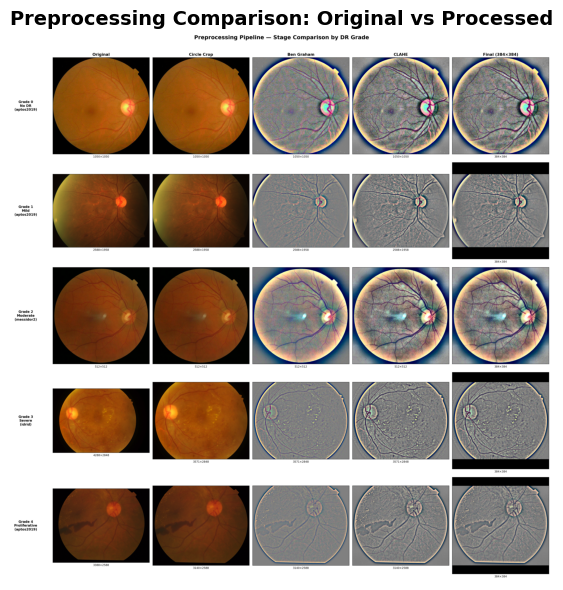

In [14]:
# Display preprocessing comparison if figure exists
preprocess_fig = ROOT / 'figures' / 'preprocessing_comparison.png'
if preprocess_fig.exists():
    img = Image.open(preprocess_fig)
    fig, ax = plt.subplots(1, 1, figsize=(14, 6))
    ax.imshow(img)
    ax.set_title('Preprocessing Comparison: Original vs Processed', fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('Preprocessing comparison figure not found. Run Notebook_01 to generate.')

---

## 4. Notebook Pipeline

The project is organized as a sequential pipeline of 12 Jupyter notebooks:

| # | Notebook | Purpose | Key Outputs |
|:-:|----------|---------|-------------|
| 00 | `Notebook_00_Dataset_Merging_EDA.ipynb` | Merge 3 datasets, MD5 deduplication, EDA | `merged_labels.csv`, EDA figures |
| 01 | `Notebook_01_Preprocessing_Pipeline.ipynb` | Image preprocessing: circle crop, Ben Graham, CLAHE | `preprocessed/`, `merged_labels_preprocessed.csv` |
| 02 | `Notebook_02_Splitting_DataLoader.ipynb` | Stratified train/val/test splits, DataLoaders | `splits/` CSVs |
| 03 | `Notebook_03APTOS_Binary_Classification.ipynb` | Binary DR classification training | `best_binary_model.pth`, training curves |
| 04 | `Notebook_04_Comprehensive_Binary_Evaluation.ipynb` | Binary model evaluation (ROC, PR, confusion matrix) | Metrics JSON, figures |
| 05 | `Notebook_05_KFold_CrossValidation.ipynb` | 5-Fold stratified cross-validation training | Fold weights, `kfold_results.csv` |
| 06 | `Notebook_06_Comprehensive_KFold_Evaluation.ipynb` | K-Fold ensemble evaluation | Ensemble predictions |
| 07 | `Notebook_07_Comprehensive_APTOS_Evaluation.ipynb` | APTOS-specific binary + ordinal evaluation | APTOS metrics |
| 08 | `Notebook_08_Comprehensive_APTOS_Evaluation.ipynb` | Extended APTOS evaluation with TTA | Ordinal QWK, threshold analysis |
| 09 | `Notebook_09_IDRiD_Prediction_Analysis.ipynb` | Cross-dataset generalization on IDRiD | IDRiD predictions |
| 10 | `Notebook_10_Prediction_Pipeline.ipynb` | General-purpose prediction pipeline | `predict.py`, clinical reports |
| 11 | `Notebook_11_Comprehensive_Prediction.ipynb` | Full prediction with Grad-CAM | Prediction reports, heatmaps |

In [16]:
# Verify all notebooks exist
notebooks = [
    'Notebook_00_Dataset_Merging_EDA.ipynb',
    'Notebook_01_Preprocessing_Pipeline.ipynb',
    'Notebook_02_Splitting_DataLoader.ipynb',
    'Notebook_03APTOS_Binary_Classification.ipynb',
    'Notebook_04_Comprehensive_Binary_Evaluation.ipynb',
    'Notebook_05_KFold_CrossValidation.ipynb',
    'Notebook_06_Comprehensive_KFold_Evaluation.ipynb',
    'Notebook_07_Comprehensive_APTOS_Evaluation.ipynb',
    'Notebook_08_Comprehensive_APTOS_Evaluation.ipynb',
    'Notebook_09_IDRiD_Prediction_Analysis.ipynb',
    'Notebook_10_Prediction_Pipeline.ipynb',
    'Notebook_11_Comprehensive_Prediction.ipynb',
]

print('=== Notebook Pipeline Verification ===')
for nb in notebooks:
    exists = (ROOT / nb).exists()
    status = 'FOUND' if exists else 'MISSING'
    icon = 'OK' if exists else 'XX'
    print(f'  [{icon}] {nb}')

found = sum(1 for nb in notebooks if (ROOT / nb).exists())
print(f'\n{found}/{len(notebooks)} notebooks found.')

=== Notebook Pipeline Verification ===
  [OK] Notebook_00_Dataset_Merging_EDA.ipynb
  [OK] Notebook_01_Preprocessing_Pipeline.ipynb
  [OK] Notebook_02_Splitting_DataLoader.ipynb
  [OK] Notebook_03APTOS_Binary_Classification.ipynb
  [OK] Notebook_04_Comprehensive_Binary_Evaluation.ipynb
  [OK] Notebook_05_KFold_CrossValidation.ipynb
  [OK] Notebook_06_Comprehensive_KFold_Evaluation.ipynb
  [OK] Notebook_07_Comprehensive_APTOS_Evaluation.ipynb
  [OK] Notebook_08_Comprehensive_APTOS_Evaluation.ipynb
  [OK] Notebook_09_IDRiD_Prediction_Analysis.ipynb
  [OK] Notebook_10_Prediction_Pipeline.ipynb
  [OK] Notebook_11_Comprehensive_Prediction.ipynb

12/12 notebooks found.


---

## 5. Results

### 5.1 Binary Classification — APTOS Test Set

In [18]:
# Load APTOS binary evaluation metrics
eval_file = ROOT / 'models' / 'aptos_binary_comprehensive_eval.json'
if eval_file.exists():
    with open(eval_file) as f:
        aptos_eval = json.load(f)
    
    m = aptos_eval['metrics']
    cm = aptos_eval['confusion_matrix']
    
    print('=' * 60)
    print('BINARY CLASSIFICATION — APTOS 2019 TEST SET')
    print('=' * 60)
    print(f'  Model:          {aptos_eval["model"]}')
    print(f'  Image Size:     {aptos_eval["image_size"]}x{aptos_eval["image_size"]}')
    print(f'  Test Size:      {aptos_eval["test_size"]} images')
    print(f'  Prevalence:     {aptos_eval["prevalence"]*100:.1f}%')
    print(f'  Opt. Threshold: {aptos_eval["optimal_threshold"]:.4f}')
    print()
    print(f'  AUC-ROC:        {m["auc_roc"]["value"]:.4f}  (95% CI: {m["auc_roc"]["ci_lower"]:.4f} - {m["auc_roc"]["ci_upper"]:.4f})')
    print(f'  AUC-PR:         {m["auc_pr"]["value"]:.4f}  (95% CI: {m["auc_pr"]["ci_lower"]:.4f} - {m["auc_pr"]["ci_upper"]:.4f})')
    print(f'  Accuracy:       {m["accuracy"]["value"]*100:.2f}%  (95% CI: {m["accuracy"]["ci_lower"]*100:.2f}% - {m["accuracy"]["ci_upper"]*100:.2f}%)')
    print(f'  Sensitivity:    {m["sensitivity"]["value"]*100:.2f}%')
    print(f'  Specificity:    {m["specificity"]["value"]*100:.2f}%')
    print(f'  Precision:      {m["precision"]*100:.2f}%')
    print(f'  NPV:            {m["npv"]*100:.2f}%')
    print(f'  F1-Score:       {m["f1_score"]["value"]:.4f}')
    print(f'  Cohen Kappa:    {m["cohen_kappa"]:.4f}')
    print(f'  MCC:            {m["mcc"]:.4f}')
    print(f'  Brier Score:    {m["brier_score"]:.4f}')
    print(f'  Log Loss:       {m["log_loss"]:.4f}')
    print()
    print(f'  Confusion Matrix:  TP={cm["tp"]}  TN={cm["tn"]}  FP={cm["fp"]}  FN={cm["fn"]}')
else:
    print('APTOS binary evaluation file not found. Run Notebook_04 first.')

BINARY CLASSIFICATION — APTOS 2019 TEST SET
  Model:          efficientnet_b3
  Image Size:     384x384
  Test Size:      531 images
  Prevalence:     49.2%
  Opt. Threshold: 0.4706

  AUC-ROC:        0.9992  (95% CI: 0.9979 - 1.0000)
  AUC-PR:         0.9992  (95% CI: 0.9979 - 0.9999)
  Accuracy:       99.06%  (95% CI: 98.12% - 99.81%)
  Sensitivity:    99.23%
  Specificity:    98.89%
  Precision:      98.85%
  NPV:            99.26%
  F1-Score:       0.9904
  Cohen Kappa:    0.9812
  MCC:            0.9812
  Brier Score:    0.0093
  Log Loss:       0.0359

  Confusion Matrix:  TP=259  TN=267  FP=3  FN=2


### 5.2 Ordinal 5-Class Grading — APTOS Test Set

In [20]:
# Load APTOS comprehensive evaluation (v2) for ordinal grading
eval_v2 = ROOT / 'evaluation' / 'aptos_comprehensive' / 'comprehensive_eval_v2.json'
if eval_v2.exists():
    with open(eval_v2) as f:
        aptos_v2 = json.load(f)
    
    ordinal = aptos_v2.get('ordinal_grading', {})
    
    print('=' * 60)
    print('ORDINAL 5-CLASS GRADING — APTOS 2019 TEST SET')
    print('=' * 60)
    
    for method_key, method_name in [('ensemble_tta', 'Ensemble + TTA'), ('twophase_tta', '2-Phase + TTA')]:
        if method_key in ordinal:
            d = ordinal[method_key]
            print(f'\n  --- {method_name} ---')
            print(f'  Quadratic Weighted Kappa (QWK): {d["qwk"]:.4f}')
            print(f'  5-Class Accuracy:              {d["accuracy_5class"]*100:.2f}%')
            if 'thresholds' in d:
                t = d['thresholds']
                print(f'  Thresholds: t1={t["t1"]:.4f}, t2={t["t2"]:.4f}, t3={t["t3"]:.4f}, t4={t["t4"]:.4f}')
    
    # Multi-level binary comparison
    levels = aptos_v2.get('evaluation_levels', {})
    if levels:
        print('\n\n  --- Binary Metrics Across Evaluation Strategies ---')
        print(f'  {"Strategy":<25s} {"AUC-ROC":>8s} {"Acc":>8s} {"Sens":>8s} {"Spec":>8s} {"F1":>8s}')
        print('  ' + '-' * 65)
        for level_name, level_data in levels.items():
            auc = level_data.get('AUC-ROC', 0)
            acc = level_data.get('Accuracy', 0)
            sens = level_data.get('Sensitivity', 0)
            spec = level_data.get('Specificity', 0)
            f1 = level_data.get('F1-Score', 0)
            print(f'  {level_name:<25s} {auc:>8.4f} {acc*100:>7.2f}% {sens*100:>7.2f}% {spec*100:>7.2f}% {f1:>8.4f}')
else:
    print('APTOS comprehensive v2 evaluation not found. Run Notebook_08 first.')

ORDINAL 5-CLASS GRADING — APTOS 2019 TEST SET

  --- Ensemble + TTA ---
  Quadratic Weighted Kappa (QWK): 0.8456
  5-Class Accuracy:              71.75%
  Thresholds: t1=0.3796, t2=0.8120, t3=0.9858, t4=0.9990

  --- 2-Phase + TTA ---
  Quadratic Weighted Kappa (QWK): 0.7147
  5-Class Accuracy:              59.70%
  Thresholds: t1=0.3107, t2=0.7579, t3=0.9954, t4=0.9990


  --- Binary Metrics Across Evaluation Strategies ---
  Strategy                   AUC-ROC      Acc     Sens     Spec       F1
  -----------------------------------------------------------------
  2-Phase (no TTA)            0.9992   98.87%   98.85%   98.89%   0.9885
  2-Phase + TTA               0.9992   98.68%   98.85%   98.52%   0.9866
  2-Phase + TTA + OptThr      0.9992   98.87%   99.62%   98.15%   0.9886
  Fold 1                      0.9979   98.87%   98.85%   98.89%   0.9885
  Fold 2                      0.9979   97.93%   96.93%   98.89%   0.9787
  Fold 3                      0.9993   98.49%   97.70%   99.26%  

### 5.3 K-Fold Cross-Validation Results — APTOS Binary

5-FOLD STRATIFIED CROSS-VALIDATION — APTOS BINARY
  Fold |  AUC-ROC |  Accuracy |  F1-Score |  Sensitivity |  Specificity |   Kappa
  --------------------------------------------------------------------------------
     1 |   0.9998 |    99.17% |    0.9915 |       98.98% |       99.35% |  0.9834
     2 |   0.9998 |    98.67% |    0.9863 |       97.29% |      100.00% |  0.9734
     3 |   0.9991 |    98.00% |    0.9797 |       98.31% |       97.71% |  0.9601
     4 |   0.9999 |    99.00% |    0.9898 |       98.31% |       99.67% |  0.9800
     5 |   0.9994 |    99.17% |    0.9915 |       98.98% |       99.34% |  0.9833
  --------------------------------------------------------------------------------
  Mean |   0.9996 |    98.80% |    0.9878 |       98.37% |       99.22% |  0.9760
   Std |   0.0003 |     0.49% |    0.0050 |        0.69% |        0.88% |  0.0098


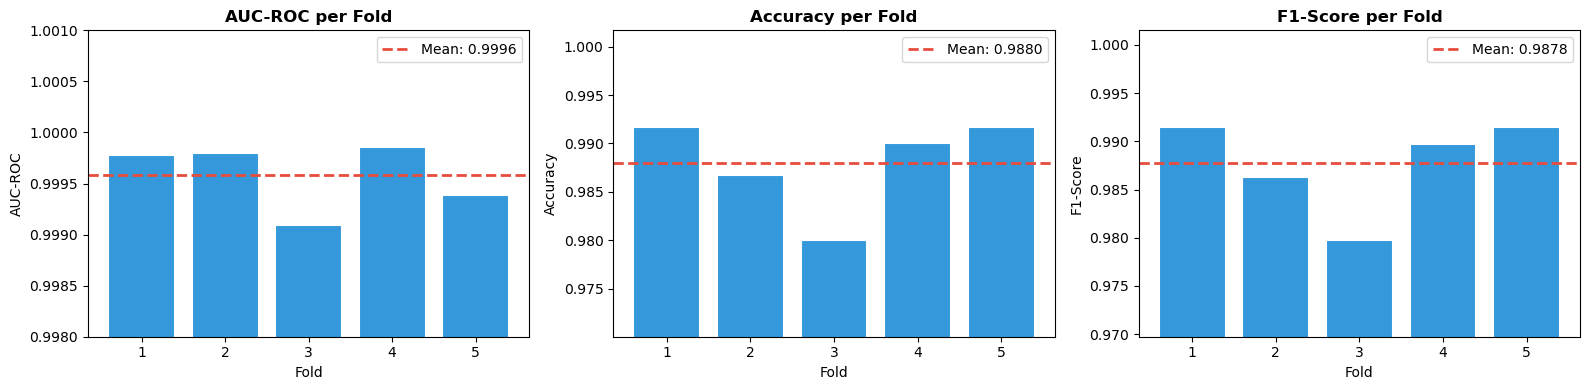

In [22]:
# Load K-Fold results
kfold_csv = ROOT / 'models' / 'kfold' / 'kfold_results.csv'
if kfold_csv.exists():
    df_kfold = pd.read_csv(kfold_csv)
    
    print('=' * 90)
    print('5-FOLD STRATIFIED CROSS-VALIDATION — APTOS BINARY')
    print('=' * 90)
    print(f'  {"Fold":>4s} | {"AUC-ROC":>8s} | {"Accuracy":>9s} | {"F1-Score":>9s} | {"Sensitivity":>12s} | {"Specificity":>12s} | {"Kappa":>7s}')
    print('  ' + '-' * 80)
    
    for _, row in df_kfold.iterrows():
        print(f'  {int(row["fold"]):>4d} | {row["auc"]:>8.4f} | {row["accuracy"]*100:>8.2f}% | {row["f1"]:>9.4f} | {row["sensitivity"]*100:>11.2f}% | {row["specificity"]*100:>11.2f}% | {row["kappa"]:>7.4f}')
    
    print('  ' + '-' * 80)
    # Mean +/- Std
    print(f'  {"Mean":>4s} | {df_kfold["auc"].mean():>8.4f} | {df_kfold["accuracy"].mean()*100:>8.2f}% | {df_kfold["f1"].mean():>9.4f} | {df_kfold["sensitivity"].mean()*100:>11.2f}% | {df_kfold["specificity"].mean()*100:>11.2f}% | {df_kfold["kappa"].mean():>7.4f}')
    print(f'  {"Std":>4s} | {df_kfold["auc"].std():>8.4f} | {df_kfold["accuracy"].std()*100:>8.2f}% | {df_kfold["f1"].std():>9.4f} | {df_kfold["sensitivity"].std()*100:>11.2f}% | {df_kfold["specificity"].std()*100:>11.2f}% | {df_kfold["kappa"].std():>7.4f}')
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    metrics_to_plot = [('auc', 'AUC-ROC'), ('accuracy', 'Accuracy'), ('f1', 'F1-Score')]
    for ax, (col, label) in zip(axes, metrics_to_plot):
        vals = df_kfold[col].values
        ax.bar(range(1, 6), vals, color='#3498db', edgecolor='white', linewidth=1.5)
        ax.axhline(y=vals.mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean: {vals.mean():.4f}')
        ax.set_xlabel('Fold')
        ax.set_ylabel(label)
        ax.set_title(f'{label} per Fold', fontweight='bold')
        ax.legend()
        ax.set_xticks(range(1, 6))
        if col == 'auc':
            ax.set_ylim(0.998, 1.001)
        else:
            ax.set_ylim(min(vals) - 0.01, max(vals) + 0.01)
    plt.tight_layout()
    plt.show()
else:
    print('K-Fold results CSV not found. Run Notebook_05 first.')

### 5.4 Cross-Dataset Generalization — Multi-Source Test Set

In [24]:
# Load KFold comprehensive evaluation on merged dataset
kfold_eval_file = ROOT / 'evaluation' / 'kfold_comprehensive' / 'comprehensive_eval.json'
if kfold_eval_file.exists():
    with open(kfold_eval_file) as f:
        kfold_eval = json.load(f)
    
    levels = kfold_eval.get('evaluation_levels', {})
    
    print('=' * 90)
    print('K-FOLD ENSEMBLE ON MULTI-SOURCE TEST SET (APTOS + IDRiD + Messidor-2)')
    print('=' * 90)
    print(f'  Test Size:  {kfold_eval["test_size"]:,} images')
    print(f'  Prevalence: {kfold_eval["prevalence"]*100:.1f}% DR')
    print(f'  TTA Times:  {kfold_eval.get("tta_times", "N/A")}')
    print()
    
    print(f'  {"Strategy":<20s} | {"AUC-ROC":>8s} | {"Acc":>8s} | {"Sens":>8s} | {"Spec":>8s} | {"F1":>8s} | {"Kappa":>7s}')
    print('  ' + '-' * 75)
    for name, data in levels.items():
        auc = data.get('AUC-ROC', 0)
        acc = data.get('Accuracy', 0)
        sens = data.get('Sensitivity', 0)
        spec = data.get('Specificity', 0)
        f1 = data.get('F1-Score', 0)
        kappa = data.get('Cohen Kappa', 0)
        print(f'  {name:<20s} | {auc:>8.4f} | {acc*100:>7.2f}% | {sens*100:>7.2f}% | {spec*100:>7.2f}% | {f1:>8.4f} | {kappa:>7.4f}')
else:
    print('KFold comprehensive evaluation not found. Run Notebook_06 first.')

K-FOLD ENSEMBLE ON MULTI-SOURCE TEST SET (APTOS + IDRiD + Messidor-2)
  Test Size:  1,021 images
  Prevalence: 51.2% DR
  TTA Times:  8

  Strategy             |  AUC-ROC |      Acc |     Sens |     Spec |       F1 |   Kappa
  ---------------------------------------------------------------------------
  Fold 1               |   0.9333 |   89.91% |   88.15% |   91.77% |   0.8995 |  0.7983
  Fold 2               |   0.9335 |   90.89% |   86.81% |   95.18% |   0.9071 |  0.8181
  Fold 3               |   0.9297 |   90.30% |   85.66% |   95.18% |   0.9005 |  0.8064
  Fold 4               |   0.9504 |   89.23% |   87.76% |   90.76% |   0.8930 |  0.7846
  Fold 5               |   0.9603 |   88.74% |   86.81% |   90.76% |   0.8876 |  0.7748
  Ensemble (no TTA)    |   0.9556 |   90.01% |   86.62% |   93.57% |   0.8988 |  0.8004
  Ensemble + TTA       |   0.9564 |   90.11% |   86.81% |   93.57% |   0.8999 |  0.8024
  Ensemble + TTA + OptThresh |   0.9564 |   90.60% |   82.98% |   98.59% |   0.90

### 5.5 Cross-Dataset — IDRiD External Evaluation

In [26]:
# Load IDRiD evaluation
idrid_eval_file = ROOT / 'evaluation' / 'idrid_comprehensive' / 'idrid_comprehensive_eval.json'
if idrid_eval_file.exists():
    with open(idrid_eval_file) as f:
        idrid_eval = json.load(f)
    
    bm = idrid_eval.get('binary_metrics', {}).get('default_threshold', {})
    
    print('=' * 60)
    print('CROSS-DATASET EVALUATION — IDRiD')
    print('=' * 60)
    print(f'  Test Size:   {idrid_eval["test_size"]} images')
    print(f'  Train Size:  {idrid_eval["train_size"]} images')
    print(f'  Prevalence:  {idrid_eval["prevalence"]*100:.1f}% DR')
    print()
    print(f'  AUC-ROC:     {bm.get("AUC-ROC", 0):.4f}')
    print(f'  AUC-PR:      {bm.get("AUC-PR", 0):.4f}')
    print(f'  Accuracy:    {bm.get("Accuracy", 0)*100:.2f}%')
    print(f'  Sensitivity: {bm.get("Sensitivity (Recall)", 0)*100:.2f}%')
    print(f'  Specificity: {bm.get("Specificity", 0)*100:.2f}%')
    print(f'  F1-Score:    {bm.get("F1-Score", 0):.4f}')
    print(f'  Cohen Kappa: {bm.get("Cohen Kappa", 0):.4f}')
    print()
    print('  Note: Lower specificity on IDRiD reflects domain shift between')
    print('  the APTOS training set and IDRiD imaging conditions/population.')
else:
    print('IDRiD evaluation not found. Run Notebook_09 first.')

CROSS-DATASET EVALUATION — IDRiD
  Test Size:   306 images
  Train Size:  1224 images
  Prevalence:  66.7% DR

  AUC-ROC:     0.8960
  AUC-PR:      0.9540
  Accuracy:    73.20%
  Sensitivity: 95.59%
  Specificity: 28.43%
  F1-Score:    0.8263
  Cohen Kappa: 0.2849

  Note: Lower specificity on IDRiD reflects domain shift between
  the APTOS training set and IDRiD imaging conditions/population.


### 5.6 Key Evaluation Figures

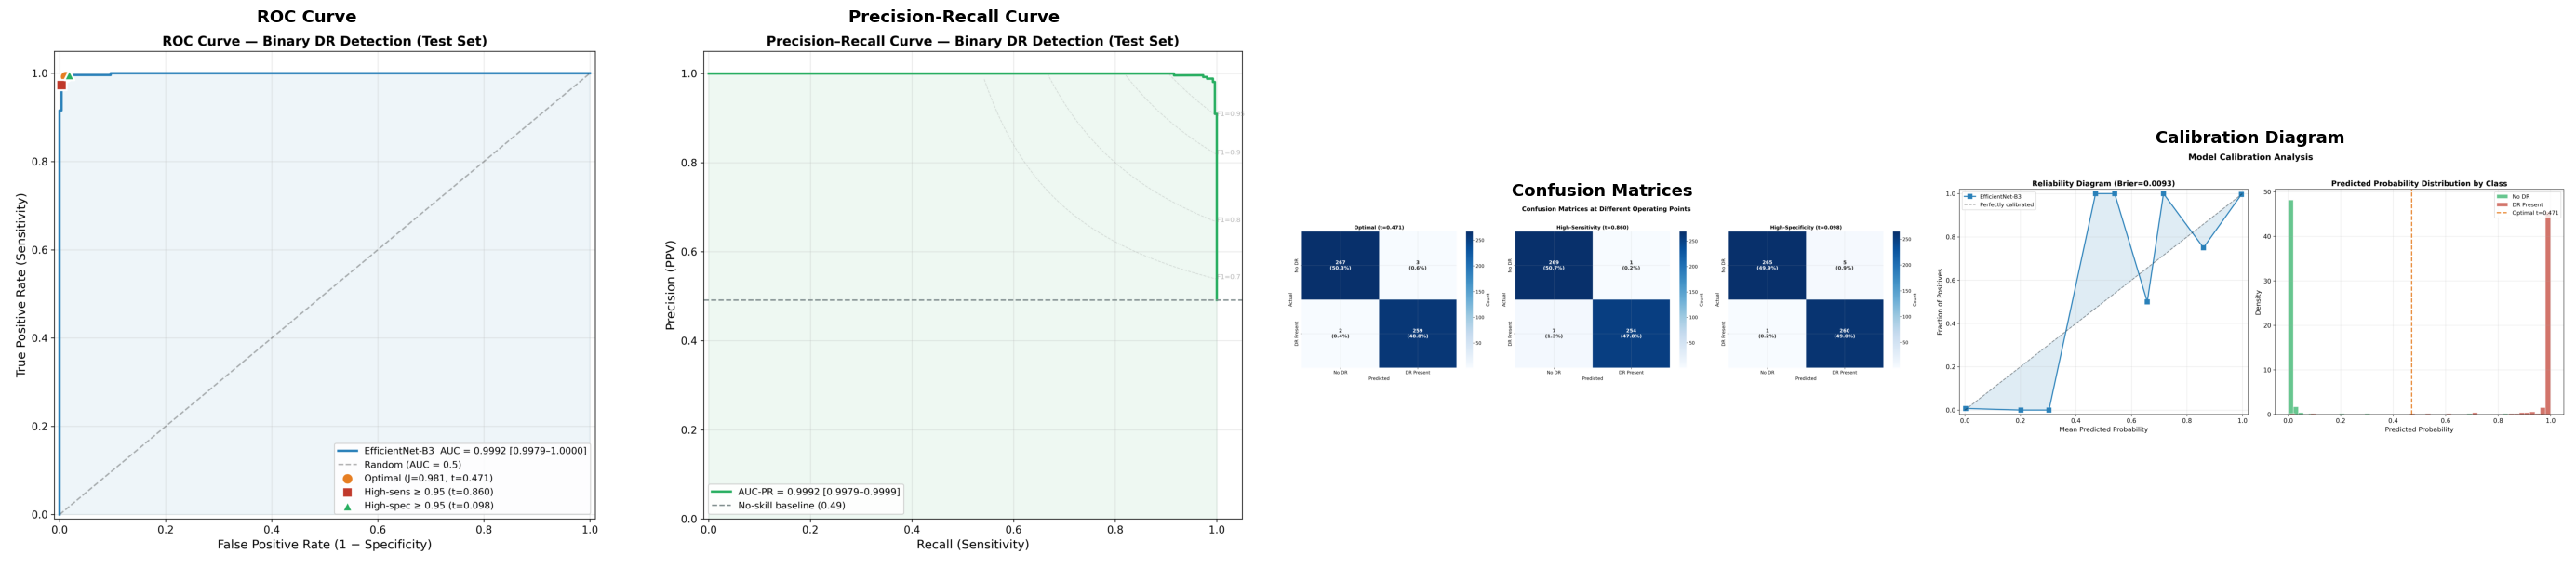

In [28]:
# Display key evaluation figures
figure_list = [
    ('figures/eval_roc_curve.png', 'ROC Curve'),
    ('figures/eval_pr_curve.png', 'Precision-Recall Curve'),
    ('figures/eval_confusion_matrices.png', 'Confusion Matrices'),
    ('figures/eval_calibration.png', 'Calibration Diagram'),
]

existing_figs = [(p, t) for p, t in figure_list if (ROOT / p).exists()]

if existing_figs:
    n = len(existing_figs)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 6))
    if n == 1:
        axes = [axes]
    for ax, (fp, title) in zip(axes, existing_figs):
        img = Image.open(ROOT / fp)
        ax.imshow(img)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('No evaluation figures found. Run Notebook_04 to generate them.')

---

## 6. Project Structure

In [30]:
structure = """
DrMulti_Binary/
|
|-- aptos2019-blindness-detection/       # APTOS 2019 dataset
|   |-- train_images/                    #   3,662 fundus PNG images
|   |-- train.csv                        #   Labels (id_code, diagnosis)
|   |-- test_images/                     #   Unlabeled test images
|
|-- IDRiD/                               # IDRiD dataset
|   |-- Train/
|   |   |-- images/                      #   Training fundus images
|   |   |-- annotations.csv              #   Training labels
|   |-- Test/
|       |-- images/                      #   Test fundus images
|       |-- annotations.csv              #   Test labels
|
|-- messidor-2/                          # Messidor-2 dataset
|   |-- messidor-2/preprocess/           #   Preprocessed PNG images
|
|-- preprocessed/                        # All images after preprocessing
|
|-- models/                              # Saved model weights
|   |-- best_binary_model.pth            #   Best binary classifier
|   |-- best_multiclass_model.pth        #   Best multi-class model
|   |-- kfold/                           #   5-Fold CV weights
|       |-- best_efficientnet_b3_fold1.pth
|       |-- ...
|       |-- best_efficientnet_b3_fold5.pth
|       |-- kfold_results.csv
|
|-- splits/                              # Merged dataset splits
|   |-- train_split.csv                  #   4,762 images
|   |-- val_split.csv                    #   1,021 images
|   |-- test_split.csv                   #   1,021 images
|
|-- splits_aptos/                        # APTOS-only splits
|   |-- train_split.csv                  #   2,473 images
|   |-- val_split.csv                    #   530 images
|   |-- test_split.csv                   #   531 images
|
|-- figures/                             # Generated plots and visualizations
|   |-- grad_cam/                        #   Grad-CAM heatmaps
|
|-- evaluation/                          # Evaluation outputs
|   |-- aptos_comprehensive/             #   APTOS eval JSONs & figures
|   |-- idrid_comprehensive/             #   IDRiD eval JSONs & figures
|   |-- kfold_comprehensive/             #   K-Fold eval JSONs & figures
|
|-- predics/                             # Prediction results & clinical reports
|
|-- merged_labels.csv                    # Unified dataset (6,804 images)
|-- merged_labels_preprocessed.csv       # Post-preprocessing CSV
|-- predict.py                           # Inference script
|-- Notebook_00-11_*.ipynb               # Pipeline notebooks
|-- README.md                            # Project documentation
"""
print(structure)


DrMulti_Binary/
|
|-- aptos2019-blindness-detection/       # APTOS 2019 dataset
|   |-- train_images/                    #   3,662 fundus PNG images
|   |-- train.csv                        #   Labels (id_code, diagnosis)
|   |-- test_images/                     #   Unlabeled test images
|
|-- IDRiD/                               # IDRiD dataset
|   |-- Train/
|   |   |-- images/                      #   Training fundus images
|   |   |-- annotations.csv              #   Training labels
|   |-- Test/
|       |-- images/                      #   Test fundus images
|       |-- annotations.csv              #   Test labels
|
|-- messidor-2/                          # Messidor-2 dataset
|   |-- messidor-2/preprocess/           #   Preprocessed PNG images
|
|-- preprocessed/                        # All images after preprocessing
|
|-- models/                              # Saved model weights
|   |-- best_binary_model.pth            #   Best binary classifier
|   |-- best_multiclass_model.

---

## 7. Installation & Setup

### Prerequisites
- Python 3.8 or higher
- NVIDIA GPU with CUDA support (recommended)
- At least 16 GB RAM

### Install Dependencies

```bash
# Create virtual environment
python -m venv venv
source venv/bin/activate

# Install PyTorch (adjust CUDA version as needed)
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# Install EfficientNet and other dependencies
pip install timm efficientnet-pytorch
pip install opencv-python pillow
pip install pandas numpy scikit-learn scipy
pip install matplotlib seaborn
pip install tqdm jupyter
```

### Dataset Setup

1. Download **APTOS 2019** from [Kaggle](https://www.kaggle.com/c/aptos2019-blindness-detection/data) → extract to `aptos2019-blindness-detection/`
2. Download **IDRiD** from [IEEE DataPort](https://ieee-dataport.org/open-access/indian-diabetic-retinopathy-image-dataset-idrid) → extract to `IDRiD/`
3. Download **Messidor-2** from [ADCIS](https://www.adcis.net/en/third-party/messidor2/) → extract to `messidor-2/`

---

## 8. Usage

### Run the Full Pipeline

Execute the notebooks sequentially:

```bash
# Step 1: Merge datasets and perform EDA
jupyter notebook Notebook_00_Dataset_Merging_EDA.ipynb

# Step 2: Preprocess all images
jupyter notebook Notebook_01_Preprocessing_Pipeline.ipynb

# Step 3: Create train/val/test splits
jupyter notebook Notebook_02_Splitting_DataLoader.ipynb

# Step 4: Train binary classifier
jupyter notebook Notebook_03APTOS_Binary_Classification.ipynb

# Step 5-11: Evaluation, cross-validation, prediction
jupyter notebook Notebook_04_Comprehensive_Binary_Evaluation.ipynb
# ... continue through Notebook_11
```

### Quick Inference

```bash
python predict.py --image path/to/fundus_image.png --model models/best_binary_model.pth
```

---

## 9. References

1. Gulshan, V., et al. (2016). "Development and validation of a deep learning algorithm for detection of diabetic retinopathy in retinal fundus photographs." *JAMA*, 316(22), 2402-2410.
2. Tan, M., & Le, Q. V. (2019). "EfficientNet: Rethinking model scaling for convolutional neural networks." *ICML 2019*.
3. Graham, B. (2015). "Kaggle Diabetic Retinopathy Detection competition, 1st place solution."
4. APTOS 2019 Blindness Detection. Kaggle. https://www.kaggle.com/c/aptos2019-blindness-detection
5. Porwal, P., et al. (2018). "Indian Diabetic Retinopathy Image Dataset (IDRiD)." *IEEE DataPort*.
6. Decenciere, E., et al. (2014). "Feedback on a publicly distributed image database: The Messidor database." *Image Analysis & Stereology*, 33(3), 231-234.

---

## 10. License & Acknowledgments

This project is for academic and research purposes. Please cite this work if you use any part of the code or methodology.

Special thanks to the creators of the APTOS 2019, IDRiD, and Messidor-2 datasets for making their data publicly available for research.

---

*Notebook generated: March 2026*